# Stage 6: 추가 개선 실험 — TTA, Augmentation, Sampler, HP 탐색

**비교 기준: Stage 4** (val F1=0.8571, val AUC=0.9942, test F1=0.700, test AUC=0.9691, threshold=0.5)

각 실험은 threshold=0.5 고정 기준으로 F1, AUC, Recall, Precision을 Stage 4와 비교한다.

## 0. 환경 설정

In [1]:
import sys
import os

# 프로젝트 루트를 sys.path에 추가 (notebooks/ 하위에서 실행 시)
# notebooks/ 하위 또는 프로젝트 루트 어느 쪽에서 실행해도 올바르게 잡힌다
from pathlib import Path
_cwd = Path(os.getcwd())
PROJECT_ROOT = str(_cwd.parent if _cwd.name == "notebooks" else _cwd)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import json
import copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import torch
from pathlib import Path

# 나눔고딕 폰트 등록
_nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(_nanum_path):
    font_manager.fontManager.addfont(_nanum_path)
    matplotlib.rcParams["font.family"] = "NanumGothic"
    print("한국어 폰트 적용: NanumGothic")
else:
    matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid", {"font.family": "NanumGothic"})

print(f"Python     : {sys.version.split()[0]}")
print(f"PyTorch    : {torch.__version__}")
print(f"CUDA 가용  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: CUDA 사용 불가 — CPU로 실행됩니다.")
print(f"Project root: {PROJECT_ROOT}")

한국어 폰트 적용: NanumGothic
Python     : 3.10.12
PyTorch    : 2.5.1+cu121
CUDA 가용  : True
GPU        : NVIDIA GeForce RTX 3060
VRAM       : 12.9 GB
Project root: /home/jinxin4u/dl/bin/projects/kolektorsdd-classification


## 1. 공통 Setup

In [2]:
from omegaconf import OmegaConf
import json

from src.utils.config import load_config, resolve_normalization
from src.data.dataset import build_dataloaders
from src.models.transfer import EfficientNetB0Transfer
from src.training.trainer import Trainer
from src.evaluation.metrics import compute_metrics
from src.evaluation.tta import TTAEvaluator

# cwd를 프로젝트 루트로 맞춰야 상대 경로가 올바르게 동작한다
os.chdir(PROJECT_ROOT)

cfg = load_config("configs/base.yaml", "configs/experiment_additional.yaml")
cfg = resolve_normalization(cfg)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

STAGE4_CHECKPOINT = "experiments/model_centric/checkpoints/best_val_f1.pth"

# Stage 4 baseline 메트릭을 results.json에서 읽음 (하드코딩 금지)
with open("experiments/model_centric/results.json") as f:
    _s4 = json.load(f)
STAGE4_BASELINE = {
    "val_f1":        _s4["metrics"]["val"]["f1"],
    "val_auc":       _s4["metrics"]["val"]["auc_roc"],
    "val_precision": _s4["metrics"]["val"]["precision"],
    "val_recall":    _s4["metrics"]["val"]["recall"],
    "test_f1":       _s4["metrics"]["test"]["f1"],
    "test_auc":      _s4["metrics"]["test"]["auc_roc"],
    "test_precision":_s4["metrics"]["test"]["precision"],
    "test_recall":   _s4["metrics"]["test"]["recall"],
}


print(f"device: {device}")
print(f"Stage 4 baseline: {STAGE4_BASELINE}")
print(f"Stage 4 checkpoint: {STAGE4_CHECKPOINT}")
assert Path(STAGE4_CHECKPOINT).exists(), f"Stage 4 체크포인트 없음: {STAGE4_CHECKPOINT}"
print("Stage 4 체크포인트 확인 완료")

device: cuda
Stage 4 baseline: {'val_f1': 0.9333333333333333, 'val_auc': 0.9970845481049563, 'val_precision': 0.875, 'val_recall': 1.0, 'test_f1': 0.8235294117647058, 'test_auc': 0.9567901234567902, 'test_precision': 0.875, 'test_recall': 0.7777777777777778}
Stage 4 checkpoint: experiments/model_centric/checkpoints/best_val_f1.pth
Stage 4 체크포인트 확인 완료


In [3]:
# 실험 결과 누적 dict — 처음 한 번만 실행
# 재실행 시 기존 결과가 지워지므로 주의
if "results" not in dir():
    results = {}
print(f"현재 저장된 실험 수: {len(results)}")

현재 저장된 실험 수: 0


## Section 1: TTA (Test Time Augmentation)

**근거:** 재학습 없이 Stage 4 체크포인트를 그대로 사용하면서, 원본+HorizontalFlip 앙상블로 방향 편향을 줄인다.
**기대효과:** FN(놓친 결함) 감소 → Recall 향상. 추가 학습 비용 없이 성능 개선 가능 여부 검증.

In [4]:
# Stage 4 체크포인트 로드 (재학습 없음)
model_tta = EfficientNetB0Transfer(cfg)
ckpt = torch.load(STAGE4_CHECKPOINT, map_location=device)
model_tta.load_state_dict(ckpt["model_state_dict"])
model_tta.to(device).eval()
print(f"Stage 4 체크포인트 로드 완료 (epoch={ckpt.get('epoch', '?')})")

_, val_loader, test_loader = build_dataloaders(cfg)

/tmp/ipykernel_154448/491017776.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(STAGE4_CHECKPOINT, map_location=device)


Stage 4 체크포인트 로드 완료 (epoch=10)


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
### TTA n_aug 비교: 3, 5, 7

tta_eval = TTAEvaluator(model=model_tta, cfg=cfg, device=device)

tta_aug_results = {}
for n_aug in [3, 5, 7]:
    val_m = tta_eval.evaluate(val_loader, threshold=0.5, n_aug=n_aug)
    test_m = tta_eval.evaluate(test_loader, threshold=0.5, n_aug=n_aug)
    key = f"TTA_n{n_aug}"
    tta_aug_results[key] = {"val": val_m, "test": test_m}
    print(
        f"[{key}] val_F1={val_m['f1']:.4f} val_AUC={val_m['auc_roc']:.4f} "
        f"| test_F1={test_m['f1']:.4f} test_AUC={test_m['auc_roc']:.4f}"
    )

# n_aug=5 결과를 대표값으로 results에 저장
results["TTA"] = tta_aug_results["TTA_n5"]
print("\nTTA 대표 결과 (n_aug=5) → results['TTA'] 저장 완료")

[TTA_n3] val_F1=0.8333 val_AUC=0.9854 | test_F1=0.6667 test_AUC=0.8930
[TTA_n5] val_F1=0.7273 val_AUC=0.9679 | test_F1=0.6667 test_AUC=0.8889
[TTA_n7] val_F1=0.7273 val_AUC=0.9563 | test_F1=0.6667 test_AUC=0.8786

TTA 대표 결과 (n_aug=5) → results['TTA'] 저장 완료


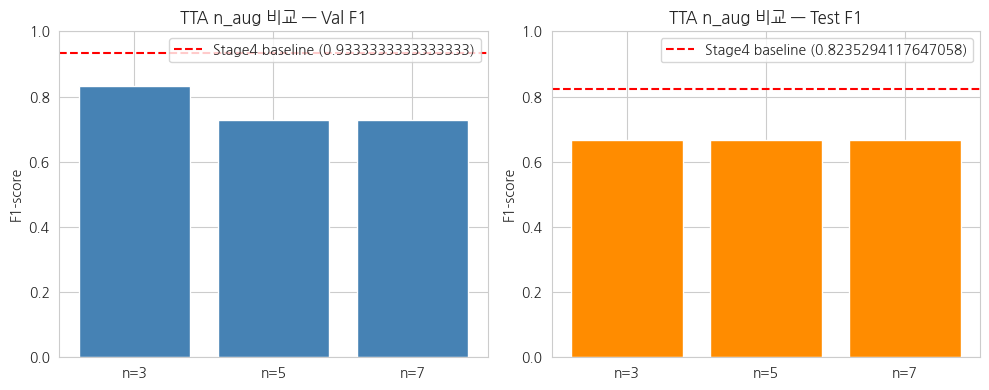

In [26]:
### TTA n_aug별 성능 비교 시각화

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
n_aug_list = [3, 5, 7]
val_f1_list = [tta_aug_results[f"TTA_n{n}"]["val"]["f1"] for n in n_aug_list]
test_f1_list = [tta_aug_results[f"TTA_n{n}"]["test"]["f1"] for n in n_aug_list]

axes[0].bar([f"n={n}" for n in n_aug_list], val_f1_list, color="steelblue")
axes[0].axhline(STAGE4_BASELINE["val_f1"], color="red", linestyle="--", label=f"Stage4 baseline ({STAGE4_BASELINE['val_f1']})")
axes[0].set_title("TTA n_aug 비교 — Val F1")
axes[0].set_ylabel("F1-score")
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar([f"n={n}" for n in n_aug_list], test_f1_list, color="darkorange")
axes[1].axhline(STAGE4_BASELINE["test_f1"], color="red", linestyle="--", label=f"Stage4 baseline ({STAGE4_BASELINE['test_f1']})")
axes[1].set_title("TTA n_aug 비교 — Test F1")
axes[1].set_ylabel("F1-score")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
os.makedirs("experiments/additional/figures", exist_ok=True)
plt.savefig("experiments/additional/figures/tta_naug_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 2: ElasticTransform p=0.15

**근거:** ElasticTransform은 산업용 결함 이미지에서 균열의 형태 변형을 모사할 수 있다.
**기대효과:** 훈련 데이터 다양성 증가로 결함 형태 변이에 대한 일반화 향상.

In [7]:
cfg_elastic = OmegaConf.merge(cfg, {})
OmegaConf.update(cfg_elastic, "augmentation.train.elastic_p", 0.15)
OmegaConf.update(cfg_elastic, "training.checkpoint_dir", "experiments/additional/elastic/checkpoints")
OmegaConf.update(cfg_elastic, "training.log_dir", "experiments/additional/elastic/logs")

print(f"elastic_p: {cfg_elastic.augmentation.train.elastic_p}")
print(f"checkpoint_dir: {cfg_elastic.training.checkpoint_dir}")

train_loader_e, val_loader_e, test_loader_e = build_dataloaders(cfg_elastic)

model_elastic = EfficientNetB0Transfer(cfg_elastic)
trainer_elastic = Trainer(model=model_elastic, cfg=cfg_elastic)
trainer_elastic.fit(train_loader_e, val_loader_e)

val_m_elastic = trainer_elastic.evaluate(val_loader_e, "val")
test_m_elastic = trainer_elastic.evaluate(test_loader_e, "test")

results["ElasticTransform_p015"] = {"val": val_m_elastic, "test": test_m_elastic}

print(
    f"\n[ElasticTransform_p015] "
    f"val_F1={val_m_elastic['f1']:.4f} val_AUC={val_m_elastic['auc_roc']:.4f} "
    f"| test_F1={test_m_elastic['f1']:.4f} test_AUC={test_m_elastic['auc_roc']:.4f}"
)
print(f"  Stage4 baseline  val_F1={STAGE4_BASELINE['val_f1']:.4f} | test_F1={STAGE4_BASELINE['test_f1']:.4f}")
print(f"  Delta val_F1 = {val_m_elastic['f1'] - STAGE4_BASELINE['val_f1']:+.4f}")
print(f"  Delta test_F1 = {test_m_elastic['f1'] - STAGE4_BASELINE['test_f1']:+.4f}")

elastic_p: 0.15
checkpoint_dir: experiments/additional/elastic/checkpoints


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:39:45 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:39:45 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:39:45 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:39:45 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-04-07 21:39:49 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2300 | val_loss=1.2725 | val_F1=0.0435 | val_AUC=0.0758
2026-04-07 21:39:49 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.0435)
2026-04-07 21:39:53 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.2122 | val_loss=1.2387 | val_F1=0.0571 | val_AUC=0.2828
2026-04-07 21:39:53 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.0571)
2026-04-07 21:39:56 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.2291 | val_loss=1.2177 | val_F1=0.2500 | val_AUC=0.4723
202

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:41:04 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=10)
2026-04-07 21:41:05 | INFO     | src.training.trainer | [val] F1=0.9231 | AUC=1.0000 | Precision=1.0000 | Recall=0.8571


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:41:05 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=10)
2026-04-07 21:41:06 | INFO     | src.training.trainer | [test] F1=0.9412 | AUC=0.9733 | Precision=1.0000 | Recall=0.8889

[ElasticTransform_p015] val_F1=0.9231 val_AUC=1.0000 | test_F1=0.9412 test_AUC=0.9733
  Stage4 baseline  val_F1=0.9333 | test_F1=0.8235
  Delta val_F1 = -0.0103
  Delta test_F1 = +0.1176


## Section 3: VerticalFlip p=0.5

**근거:** KolektorSDD 이미지는 수직 방향으로도 유효한 변형이 발생할 수 있다. VerticalFlip을 학습에 추가하면 위아래 방향에 대한 불변성을 학습할 수 있다.
**기대효과:** 방향 다양성 증가로 test 일반화 개선 기대.

In [8]:
cfg_vflip = OmegaConf.merge(cfg, {})
OmegaConf.update(cfg_vflip, "augmentation.train.vertical_flip_p", 0.5)
OmegaConf.update(cfg_vflip, "training.checkpoint_dir", "experiments/additional/vflip/checkpoints")
OmegaConf.update(cfg_vflip, "training.log_dir", "experiments/additional/vflip/logs")

print(f"vertical_flip_p: {cfg_vflip.augmentation.train.vertical_flip_p}")
print(f"checkpoint_dir: {cfg_vflip.training.checkpoint_dir}")

train_loader_v, val_loader_v, test_loader_v = build_dataloaders(cfg_vflip)

model_vflip = EfficientNetB0Transfer(cfg_vflip)
trainer_vflip = Trainer(model=model_vflip, cfg=cfg_vflip)
trainer_vflip.fit(train_loader_v, val_loader_v)

val_m_vflip = trainer_vflip.evaluate(val_loader_v, "val")
test_m_vflip = trainer_vflip.evaluate(test_loader_v, "test")

results["VerticalFlip_p05"] = {"val": val_m_vflip, "test": test_m_vflip}

print(
    f"\n[VerticalFlip_p05] "
    f"val_F1={val_m_vflip['f1']:.4f} val_AUC={val_m_vflip['auc_roc']:.4f} "
    f"| test_F1={test_m_vflip['f1']:.4f} test_AUC={test_m_vflip['auc_roc']:.4f}"
)
print(f"  Stage4 baseline  val_F1={STAGE4_BASELINE['val_f1']:.4f} | test_F1={STAGE4_BASELINE['test_f1']:.4f}")
print(f"  Delta val_F1 = {val_m_vflip['f1'] - STAGE4_BASELINE['val_f1']:+.4f}")
print(f"  Delta test_F1 = {test_m_vflip['f1'] - STAGE4_BASELINE['test_f1']:+.4f}")

vertical_flip_p: 0.5
checkpoint_dir: experiments/additional/vflip/checkpoints


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:41:11 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:41:11 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:41:11 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:41:11 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-04-07 21:41:15 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2070 | val_loss=1.1574 | val_F1=0.3750 | val_AUC=0.6997
2026-04-07 21:41:15 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.3750)
2026-04-07 21:41:18 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.1980 | val_loss=1.1543 | val_F1=0.3429 | val_AUC=0.7434
2026-04-07 21:41:21 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.1989 | val_loss=1.1580 | val_F1=0.2857 | val_AUC=0.6793
2026-04-07 21:41:24 | INFO     | src.training.trainer | Epoch   4/30 | train_loss=1.1842 | val

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:42:25 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=11)
2026-04-07 21:42:26 | INFO     | src.training.trainer | [val] F1=1.0000 | AUC=1.0000 | Precision=1.0000 | Recall=1.0000


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:42:26 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=11)
2026-04-07 21:42:27 | INFO     | src.training.trainer | [test] F1=0.6667 | AUC=0.8992 | Precision=0.8333 | Recall=0.5556

[VerticalFlip_p05] val_F1=1.0000 val_AUC=1.0000 | test_F1=0.6667 test_AUC=0.8992
  Stage4 baseline  val_F1=0.9333 | test_F1=0.8235
  Delta val_F1 = +0.0667
  Delta test_F1 = -0.1569


## Section 4: WeightedRandomSampler 단독

**근거:** pos_weight는 손실 함수에서 클래스 불균형을 보정하고, WeightedRandomSampler는 미니배치 샘플링 단계에서 보정한다. 두 방식의 효과를 분리하기 위해 pos_weight=null 상태에서 Sampler만 단독으로 사용한다.

**기대효과:** 배치 내 클래스 균형 향상 → 소수 클래스(결함) 학습 신호 증폭.

In [9]:
cfg_sampler = OmegaConf.merge(cfg, {})
OmegaConf.update(cfg_sampler, "data.use_weighted_sampler", True)
# pos_weight=1.0: 가중치 없음 (WeightedSampler가 배치 균등화를 담당하므로 손실 가중치는 비활성화)
# null로 두면 Trainer가 state.yaml 기반으로 자동 계산(6.78)하므로 반드시 명시 필요
OmegaConf.update(cfg_sampler, "loss.pos_weight", 1.0)
OmegaConf.update(cfg_sampler, "training.checkpoint_dir", "experiments/additional/sampler/checkpoints")
OmegaConf.update(cfg_sampler, "training.log_dir", "experiments/additional/sampler/logs")

print(f"use_weighted_sampler: {cfg_sampler.data.use_weighted_sampler}")
print(f"loss.pos_weight: {cfg_sampler.loss.pos_weight}")

train_loader_s, val_loader_s, test_loader_s = build_dataloaders(cfg_sampler)

model_sampler = EfficientNetB0Transfer(cfg_sampler)
trainer_sampler = Trainer(model=model_sampler, cfg=cfg_sampler)
trainer_sampler.fit(train_loader_s, val_loader_s)

val_m_sampler = trainer_sampler.evaluate(val_loader_s, "val")
test_m_sampler = trainer_sampler.evaluate(test_loader_s, "test")

results["WeightedSampler_only"] = {"val": val_m_sampler, "test": test_m_sampler}

print(f"[WeightedSampler_only] "
    f"val_F1={val_m_sampler['f1']:.4f} val_AUC={val_m_sampler['auc_roc']:.4f} "
    f"| test_F1={test_m_sampler['f1']:.4f} test_AUC={test_m_sampler['auc_roc']:.4f}"
)
print(f"  Stage4 baseline  val_F1={STAGE4_BASELINE['val_f1']:.4f} | test_F1={STAGE4_BASELINE['test_f1']:.4f}")
print(f"  Delta val_F1 = {val_m_sampler['f1'] - STAGE4_BASELINE['val_f1']:+.4f}")
print(f"  Delta test_F1 = {test_m_sampler['f1'] - STAGE4_BASELINE['test_f1']:+.4f}")

use_weighted_sampler: True
loss.pos_weight: 1.0


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:42:55 | INFO     | src.training.trainer | pos_weight 명시값 사용: 1.0
2026-04-07 21:42:55 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=1.0000)
2026-04-07 21:42:55 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:42:55 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-04-07 21:42:58 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=0.6860 | val_loss=0.7072 | val_F1=0.2553 | val_AUC=0.5598
2026-04-07 21:42:58 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2553)
2026-04-07 21:43:01 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=0.6941 | val_loss=0.6712 | val_F1=0.1600 | val_AUC=0.4752
2026-04-07 21:43:05 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=0.6744 | val_loss=0.7434 | val_F1=0.2692 | val_AUC=0.6181
2026-04-07 21:43:05 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2692)
2026-04-07 21:

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:44:21 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=15)
2026-04-07 21:44:22 | INFO     | src.training.trainer | [val] F1=0.9231 | AUC=0.9971 | Precision=1.0000 | Recall=0.8571


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:44:22 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=15)
2026-04-07 21:44:23 | INFO     | src.training.trainer | [test] F1=0.9412 | AUC=0.9979 | Precision=1.0000 | Recall=0.8889
[WeightedSampler_only] val_F1=0.9231 val_AUC=0.9971 | test_F1=0.9412 test_AUC=0.9979
  Stage4 baseline  val_F1=0.9333 | test_F1=0.8235
  Delta val_F1 = -0.0103
  Delta test_F1 = +0.1176


## Section 5: 하이퍼파라미터 탐색 (One-at-a-time)

One-at-a-time 방식 — 각 실험마다 탐색 대상 파라미터만 변경하고 나머지는 Stage 4 기준값 유지.
탐색 파라미터: lr, frozen_epochs, weight_decay, batch_size, dropout_rate

In [10]:
### HP 실험 헬퍼 함수

def run_hp_experiment(base_cfg, overrides: dict, exp_name: str) -> dict:
    """
    base_cfg에서 overrides를 적용하고 학습/평가 후 결과를 반환한다.

    Args:
        base_cfg: 기본 OmegaConf config (Stage 4 기준값)
        overrides: {key: value} — OmegaConf.update로 적용할 오버라이드
        exp_name: 실험명 (checkpoint_dir 하위 폴더명으로 사용)

    Returns:
        {"val": metrics_dict, "test": metrics_dict}
    """
    cfg_hp = OmegaConf.merge(base_cfg, {})
    for key, value in overrides.items():
        OmegaConf.update(cfg_hp, key, value)
    OmegaConf.update(cfg_hp, "training.checkpoint_dir", f"experiments/additional/{exp_name}/checkpoints")
    OmegaConf.update(cfg_hp, "training.log_dir", f"experiments/additional/{exp_name}/logs")

    print(f"\n[{exp_name}] 설정 확인:")
    for key, value in overrides.items():
        print(f"  {key} = {value}")

    train_loader_hp, val_loader_hp, test_loader_hp = build_dataloaders(cfg_hp)
    model_hp = EfficientNetB0Transfer(cfg_hp)
    trainer_hp = Trainer(model=model_hp, cfg=cfg_hp)
    trainer_hp.fit(train_loader_hp, val_loader_hp)

    val_m = trainer_hp.evaluate(val_loader_hp, "val")
    test_m = trainer_hp.evaluate(test_loader_hp, "test")

    print(
        f"[{exp_name}] val_F1={val_m['f1']:.4f} val_AUC={val_m['auc_roc']:.4f} "
        f"| test_F1={test_m['f1']:.4f} test_AUC={test_m['auc_roc']:.4f}"
    )
    print(f"  Delta val_F1={val_m['f1'] - STAGE4_BASELINE['val_f1']:+.4f}  Delta test_F1={test_m['f1'] - STAGE4_BASELINE['test_f1']:+.4f}")
    return {"val": val_m, "test": test_m}

print("run_hp_experiment 헬퍼 정의 완료")

run_hp_experiment 헬퍼 정의 완료


### HP 탐색 1: lr=5e-4 (phase2_lr=5e-5)

**근거:** 기본값 lr=1e-3은 Phase 1에서 수렴이 빠르지만 과적합 위험이 있다. lr=5e-4로 낮추면 더 안정적인 수렴을 기대할 수 있다. phase2_lr은 lr의 1/10 비율을 유지한다.

In [11]:
results["hp_lr_5e4"] = run_hp_experiment(
    cfg,
    overrides={"training.lr": 5e-4, "training.phase2_lr": 5e-5},
    exp_name="hp_lr_5e4",
)


[hp_lr_5e4] 설정 확인:
  training.lr = 0.0005
  training.phase2_lr = 5e-05


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:45:49 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:45:49 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:45:49 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:45:49 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.0005)
2026-04-07 21:45:52 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2169 | val_loss=1.1526 | val_F1=0.4444 | val_AUC=0.8746
2026-04-07 21:45:52 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.4444)
2026-04-07 21:45:55 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.1942 | val_loss=1.1583 | val_F1=0.2353 | val_AUC=0.7813
2026-04-07 21:45:58 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.1910 | val_loss=1.1701 | val_F1=0.2222 | val_AUC=0.7143
2026-04-07 21:46:02 | INFO     | src.training.trainer | Epoch   4/30 | train_loss=1.1931 | va

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:47:21 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=16)
2026-04-07 21:47:21 | INFO     | src.training.trainer | [val] F1=0.9231 | AUC=0.9883 | Precision=1.0000 | Recall=0.8571


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:47:22 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=16)
2026-04-07 21:47:22 | INFO     | src.training.trainer | [test] F1=0.6667 | AUC=0.9630 | Precision=0.6667 | Recall=0.6667
[hp_lr_5e4] val_F1=0.9231 val_AUC=0.9883 | test_F1=0.6667 test_AUC=0.9630
  Delta val_F1=-0.0103  Delta test_F1=-0.1569


### HP 탐색 2: lr=1e-4 (phase2_lr=1e-5)

**근거:** lr=1e-4는 보수적인 학습률로 EfficientNet 미세조정에서 안정적인 결과를 내는 경우가 많다. 수렴 속도는 느리지만 early stopping이 있으므로 크게 불리하지 않다.

In [12]:
results["hp_lr_1e4"] = run_hp_experiment(
    cfg,
    overrides={"training.lr": 1e-4, "training.phase2_lr": 1e-5},
    exp_name="hp_lr_1e4",
)


[hp_lr_1e4] 설정 확인:
  training.lr = 0.0001
  training.phase2_lr = 1e-05


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:47:45 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:47:45 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:47:45 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:47:45 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.0001)
2026-04-07 21:47:48 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2500 | val_loss=1.2166 | val_F1=0.1538 | val_AUC=0.4082
2026-04-07 21:47:48 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.1538)
2026-04-07 21:47:52 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.2151 | val_loss=1.2029 | val_F1=0.2069 | val_AUC=0.4752
2026-04-07 21:47:52 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2069)
2026-04-07 21:47:55 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.2211 | val_loss=1.2119 | val_F1=0.2273 | val_AUC=0.4227
20

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:48:51 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=9)
2026-04-07 21:48:52 | INFO     | src.training.trainer | [val] F1=0.3846 | AUC=0.6793 | Precision=0.2632 | Recall=0.7143


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:48:52 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=9)
2026-04-07 21:48:53 | INFO     | src.training.trainer | [test] F1=0.3478 | AUC=0.7490 | Precision=0.2857 | Recall=0.4444
[hp_lr_1e4] val_F1=0.3846 val_AUC=0.6793 | test_F1=0.3478 test_AUC=0.7490
  Delta val_F1=-0.5487  Delta test_F1=-0.4757


### HP 탐색 3: frozen_epochs=3

**근거:** frozen_epochs=3으로 줄이면 Phase 2(full fine-tuning)로 더 빨리 전환한다. backbone 특징이 이미 ImageNet으로 잘 초기화되어 있으므로 짧은 warm-up으로도 충분할 수 있다.

In [13]:
results["hp_frozen3"] = run_hp_experiment(
    cfg,
    overrides={"training.frozen_epochs": 3},
    exp_name="hp_frozen3",
)


[hp_frozen3] 설정 확인:
  training.frozen_epochs = 3


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:49:43 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:49:43 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:49:43 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:49:43 | INFO     | src.training.trainer | Phase 1: epoch 1~3 — classifier only (lr=0.001)
2026-04-07 21:49:46 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2243 | val_loss=1.2110 | val_F1=0.1569 | val_AUC=0.3411
2026-04-07 21:49:46 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.1569)
2026-04-07 21:49:49 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.1745 | val_loss=1.2028 | val_F1=0.2333 | val_AUC=0.6035
2026-04-07 21:49:49 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2333)
2026-04-07 21:49:52 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.2236 | val_loss=1.2125 | val_F1=0.2258 | val_AUC=0.5539
202

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:50:49 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=9)
2026-04-07 21:50:50 | INFO     | src.training.trainer | [val] F1=0.9231 | AUC=0.9796 | Precision=1.0000 | Recall=0.8571


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:50:50 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=9)
2026-04-07 21:50:51 | INFO     | src.training.trainer | [test] F1=0.6667 | AUC=0.9506 | Precision=0.5833 | Recall=0.7778
[hp_frozen3] val_F1=0.9231 val_AUC=0.9796 | test_F1=0.6667 test_AUC=0.9506
  Delta val_F1=-0.0103  Delta test_F1=-0.1569


### HP 탐색 4: frozen_epochs=10

**근거:** frozen_epochs=10으로 늘리면 classifier head를 더 오래 학습한 후 fine-tuning을 시작한다. 데이터가 작을 때 backbone을 너무 일찍 열면 overfitting이 심해질 수 있으므로 긴 warm-up의 효과를 검증한다.

In [14]:
results["hp_frozen10"] = run_hp_experiment(
    cfg,
    overrides={"training.frozen_epochs": 10},
    exp_name="hp_frozen10",
)


[hp_frozen10] 설정 확인:
  training.frozen_epochs = 10


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:52:26 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:52:26 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:52:26 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:52:26 | INFO     | src.training.trainer | Phase 1: epoch 1~10 — classifier only (lr=0.001)
2026-04-07 21:52:29 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2207 | val_loss=1.2190 | val_F1=0.1967 | val_AUC=0.3003
2026-04-07 21:52:29 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.1967)
2026-04-07 21:52:32 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.1941 | val_loss=1.1983 | val_F1=0.2381 | val_AUC=0.4927
2026-04-07 21:52:32 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2381)
2026-04-07 21:52:35 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.1964 | val_loss=1.1960 | val_F1=0.2381 | val_AUC=0.5131
20

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:53:51 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=15)
2026-04-07 21:53:52 | INFO     | src.training.trainer | [val] F1=1.0000 | AUC=1.0000 | Precision=1.0000 | Recall=1.0000


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:53:52 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=15)
2026-04-07 21:53:53 | INFO     | src.training.trainer | [test] F1=0.7000 | AUC=0.9444 | Precision=0.6364 | Recall=0.7778
[hp_frozen10] val_F1=1.0000 val_AUC=1.0000 | test_F1=0.7000 test_AUC=0.9444
  Delta val_F1=+0.0667  Delta test_F1=-0.1235


### HP 탐색 5: weight_decay=1e-3

**근거:** weight_decay를 10배 높이면 L2 정규화가 강화되어 소량 데이터(399장)에서의 과적합 억제 효과를 기대할 수 있다.

In [15]:
results["hp_wd_1e3"] = run_hp_experiment(
    cfg,
    overrides={"training.weight_decay": 1e-3},
    exp_name="hp_wd_1e3",
)


[hp_wd_1e3] 설정 확인:
  training.weight_decay = 0.001


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:53:56 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:53:56 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:53:56 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:53:56 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-04-07 21:53:59 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2707 | val_loss=1.2329 | val_F1=0.1818 | val_AUC=0.3090
2026-04-07 21:53:59 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.1818)
2026-04-07 21:54:02 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.1906 | val_loss=1.2018 | val_F1=0.0833 | val_AUC=0.4548
2026-04-07 21:54:05 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.1997 | val_loss=1.1705 | val_F1=0.2632 | val_AUC=0.6531
2026-04-07 21:54:05 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2632)
202

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:55:11 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=11)
2026-04-07 21:55:11 | INFO     | src.training.trainer | [val] F1=1.0000 | AUC=1.0000 | Precision=1.0000 | Recall=1.0000


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:55:12 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=11)
2026-04-07 21:55:12 | INFO     | src.training.trainer | [test] F1=0.7778 | AUC=0.9794 | Precision=0.7778 | Recall=0.7778
[hp_wd_1e3] val_F1=1.0000 val_AUC=1.0000 | test_F1=0.7778 test_AUC=0.9794
  Delta val_F1=+0.0667  Delta test_F1=-0.0458


### HP 탐색 6: weight_decay=0

**근거:** weight_decay=0은 L2 정규화를 완전히 제거한다. Dropout과 pos_weight가 이미 정규화 역할을 하고 있으므로, weight_decay 제거가 오히려 학습 자유도를 높일 수 있다.

In [16]:
results["hp_wd_0"] = run_hp_experiment(
    cfg,
    overrides={"training.weight_decay": 0.0},
    exp_name="hp_wd_0",
)


[hp_wd_0] 설정 확인:
  training.weight_decay = 0.0


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:55:21 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:55:21 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:55:21 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:55:21 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-04-07 21:55:24 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2420 | val_loss=1.1962 | val_F1=0.2222 | val_AUC=0.5044
2026-04-07 21:55:24 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2222)
2026-04-07 21:55:27 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.1827 | val_loss=1.1781 | val_F1=0.2692 | val_AUC=0.6647
2026-04-07 21:55:27 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2692)
2026-04-07 21:55:30 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.2025 | val_loss=1.1734 | val_F1=0.2295 | val_AUC=0.7551
202

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:56:30 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=10)
2026-04-07 21:56:31 | INFO     | src.training.trainer | [val] F1=1.0000 | AUC=1.0000 | Precision=1.0000 | Recall=1.0000


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:56:31 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=10)
2026-04-07 21:56:32 | INFO     | src.training.trainer | [test] F1=0.7778 | AUC=0.9383 | Precision=0.7778 | Recall=0.7778
[hp_wd_0] val_F1=1.0000 val_AUC=1.0000 | test_F1=0.7778 test_AUC=0.9383
  Delta val_F1=+0.0667  Delta test_F1=-0.0458


### HP 탐색 7: batch_size=16

**근거:** 배치 크기를 절반으로 줄이면 gradient noise가 증가하여 정규화 효과를 얻고, 소량 데이터셋에서 gradient 업데이트 빈도가 높아진다.

In [17]:
results["hp_bs16"] = run_hp_experiment(
    cfg,
    overrides={"training.batch_size": 16},
    exp_name="hp_bs16",
)


[hp_bs16] 설정 확인:
  training.batch_size = 16


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:56:36 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:56:36 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:56:36 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:56:36 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-04-07 21:56:39 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2248 | val_loss=1.1763 | val_F1=0.2632 | val_AUC=0.6327
2026-04-07 21:56:40 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2632)
2026-04-07 21:56:43 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.1628 | val_loss=1.1593 | val_F1=0.2963 | val_AUC=0.6356
2026-04-07 21:56:43 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2963)
2026-04-07 21:56:46 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.2007 | val_loss=1.1127 | val_F1=0.2791 | val_AUC=0.7697
202

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:58:01 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=12)
2026-04-07 21:58:01 | INFO     | src.training.trainer | [val] F1=0.9231 | AUC=0.9971 | Precision=1.0000 | Recall=0.8571


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:58:02 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=12)
2026-04-07 21:58:02 | INFO     | src.training.trainer | [test] F1=0.8235 | AUC=0.9938 | Precision=0.8750 | Recall=0.7778
[hp_bs16] val_F1=0.9231 val_AUC=0.9971 | test_F1=0.8235 test_AUC=0.9938
  Delta val_F1=-0.0103  Delta test_F1=+0.0000


### HP 탐색 8: dropout_rate=0.3

**근거:** 기본 dropout_rate=0.2 대비 0.3으로 높이면 classifier head의 정규화를 강화할 수 있다. 소량 데이터에서 dropout이 과적합 방지에 도움이 된다.

In [18]:
results["hp_dropout03"] = run_hp_experiment(
    cfg,
    overrides={"model.dropout_rate": 0.3},
    exp_name="hp_dropout03",
)


[hp_dropout03] 설정 확인:
  model.dropout_rate = 0.3


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:58:07 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:58:07 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:58:07 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:58:07 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-04-07 21:58:10 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2266 | val_loss=1.1722 | val_F1=0.2553 | val_AUC=0.6589
2026-04-07 21:58:10 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2553)
2026-04-07 21:58:13 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.1777 | val_loss=1.1988 | val_F1=0.2000 | val_AUC=0.5510
2026-04-07 21:58:16 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.2002 | val_loss=1.1676 | val_F1=0.2500 | val_AUC=0.6385
2026-04-07 21:58:20 | INFO     | src.training.trainer | Epoch   4/30 | train_loss=1.2024 | val

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:59:43 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=17)
2026-04-07 21:59:43 | INFO     | src.training.trainer | [val] F1=1.0000 | AUC=1.0000 | Precision=1.0000 | Recall=1.0000


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 21:59:44 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=17)
2026-04-07 21:59:44 | INFO     | src.training.trainer | [test] F1=0.8889 | AUC=0.9938 | Precision=0.8889 | Recall=0.8889
[hp_dropout03] val_F1=1.0000 val_AUC=1.0000 | test_F1=0.8889 test_AUC=0.9938
  Delta val_F1=+0.0667  Delta test_F1=+0.0654


### HP 탐색 9: dropout_rate=0.5

**근거:** dropout_rate=0.5는 일반적으로 분류 헤드에서 많이 사용하는 값이다. 강한 정규화 효과를 확인한다.

In [19]:
results["hp_dropout05"] = run_hp_experiment(
    cfg,
    overrides={"model.dropout_rate": 0.5},
    exp_name="hp_dropout05",
)


[hp_dropout05] 설정 확인:
  model.dropout_rate = 0.5


/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


2026-04-07 21:59:49 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-04-07 21:59:49 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-04-07 21:59:49 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-04-07 21:59:49 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-04-07 21:59:52 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2797 | val_loss=1.1866 | val_F1=0.0000 | val_AUC=0.7085
2026-04-07 21:59:52 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.0000)
2026-04-07 21:59:56 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.2003 | val_loss=1.1795 | val_F1=0.0000 | val_AUC=0.6793
2026-04-07 21:59:59 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.2431 | val_loss=1.1683 | val_F1=0.0000 | val_AUC=0.6851
2026-04-07 22:00:02 | INFO     | src.training.trainer | Epoch   4/30 | train_loss=1.2015 | val

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 22:01:08 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=12)
2026-04-07 22:01:09 | INFO     | src.training.trainer | [val] F1=0.9333 | AUC=0.9942 | Precision=0.8750 | Recall=1.0000


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-04-07 22:01:09 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=12)
2026-04-07 22:01:10 | INFO     | src.training.trainer | [test] F1=0.7778 | AUC=0.9362 | Precision=0.7778 | Recall=0.7778
[hp_dropout05] val_F1=0.9333 val_AUC=0.9942 | test_F1=0.7778 test_AUC=0.9362
  Delta val_F1=+0.0000  Delta test_F1=-0.0458


## Section 6: 결과 비교표

In [20]:
# Stage 4 기준값 포함 비교표 구성
rows = [{
    "experiment":    "Stage4_Baseline",
    "val_f1":        STAGE4_BASELINE["val_f1"],
    "val_auc":       STAGE4_BASELINE["val_auc"],
    "val_precision": STAGE4_BASELINE["val_precision"],
    "val_recall":    STAGE4_BASELINE["val_recall"],
    "test_f1":       STAGE4_BASELINE["test_f1"],
    "test_auc":      STAGE4_BASELINE["test_auc"],
    "test_precision":STAGE4_BASELINE["test_precision"],
    "test_recall":   STAGE4_BASELINE["test_recall"],
}]

for name, r in results.items():
    rows.append({
        "experiment": name,
        "val_f1": r["val"]["f1"],
        "val_auc": r["val"]["auc_roc"],
        "val_precision": r["val"]["precision"],
        "val_recall": r["val"]["recall"],
        "test_f1": r["test"]["f1"],
        "test_auc": r["test"]["auc_roc"],
        "test_precision": r["test"]["precision"],
        "test_recall": r["test"]["recall"],
    })

df = pd.DataFrame(rows)

# Stage 4 대비 delta 컬럼 추가
df["val_f1_delta"] = df["val_f1"] - STAGE4_BASELINE["val_f1"]
df["test_f1_delta"] = df["test_f1"] - STAGE4_BASELINE["test_f1"]

# 표시 포맷
display_cols = ["experiment", "val_f1", "val_auc", "val_precision", "val_recall",
                "test_f1", "test_auc", "test_precision", "test_recall",
                "val_f1_delta", "test_f1_delta"]

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

print("=== 전체 실험 결과 비교 (threshold=0.5) ===")
print(df[display_cols].to_string(index=False))

=== 전체 실험 결과 비교 (threshold=0.5) ===
           experiment  val_f1  val_auc  val_precision  val_recall  test_f1  test_auc  test_precision  test_recall  val_f1_delta  test_f1_delta
      Stage4_Baseline  0.9333   0.9971         0.8750      1.0000   0.8235    0.9568          0.8750       0.7778        0.0000         0.0000
                  TTA  0.7273   0.9679         1.0000      0.5714   0.6667    0.8889          0.8333       0.5556       -0.2061        -0.1569
ElasticTransform_p015  0.9231   1.0000         1.0000      0.8571   0.9412    0.9733          1.0000       0.8889       -0.0103         0.1176
     VerticalFlip_p05  1.0000   1.0000         1.0000      1.0000   0.6667    0.8992          0.8333       0.5556        0.0667        -0.1569
 WeightedSampler_only  0.9231   0.9971         1.0000      0.8571   0.9412    0.9979          1.0000       0.8889       -0.0103         0.1176
            hp_lr_5e4  0.9231   0.9883         1.0000      0.8571   0.6667    0.9630          0.6667      

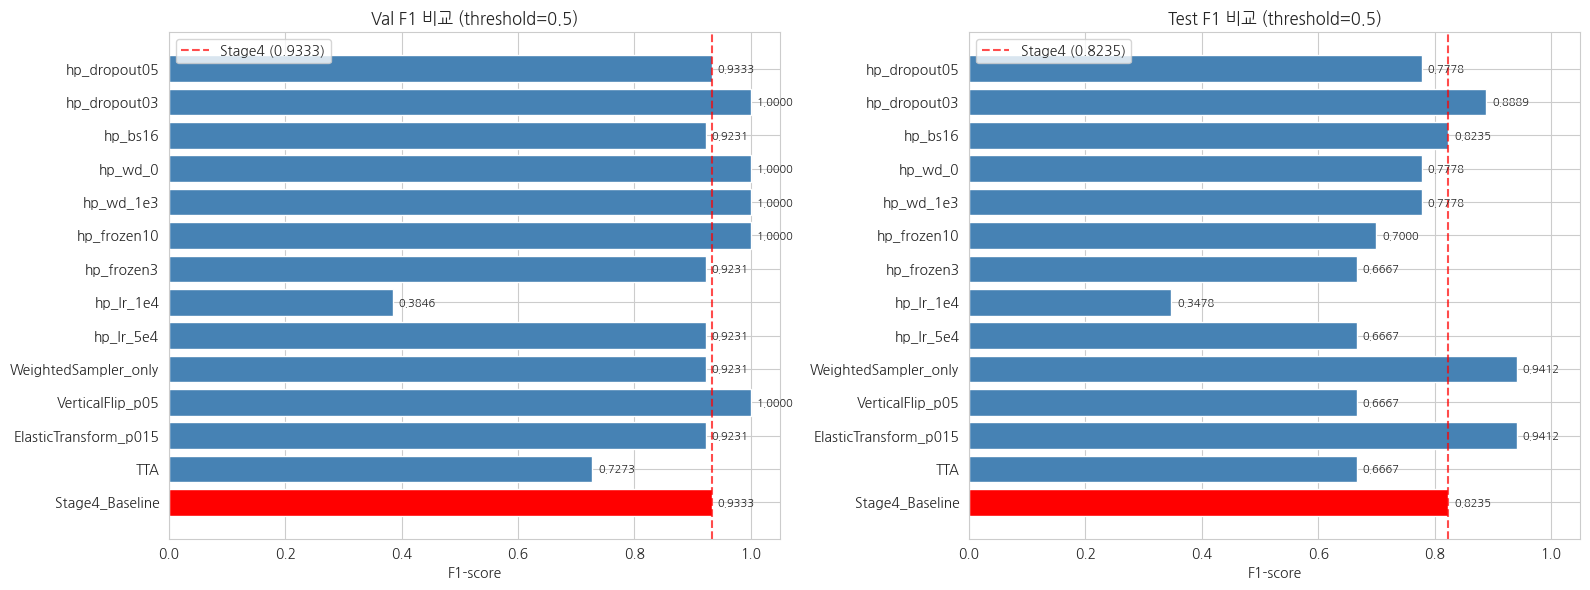

comparison_f1.png 저장 완료


In [27]:
### test_f1 비교 막대그래프

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stage4 Baseline을 빨간 점선으로 표시, 나머지 실험은 색상으로 구분
exp_names = df["experiment"].tolist()
val_f1_vals = df["val_f1"].tolist()
test_f1_vals = df["test_f1"].tolist()

colors = ["red" if n == "Stage4_Baseline" else "steelblue" for n in exp_names]

# Val F1
axes[0].barh(exp_names, val_f1_vals, color=colors)
axes[0].axvline(STAGE4_BASELINE["val_f1"], color="red", linestyle="--", alpha=0.7, label=f"Stage4 ({STAGE4_BASELINE['val_f1']:.4f})")
axes[0].set_title("Val F1 비교 (threshold=0.5)")
axes[0].set_xlabel("F1-score")
axes[0].set_xlim(0, 1.05)
axes[0].legend()
for i, v in enumerate(val_f1_vals):
    if v is not None:
        axes[0].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=8)

# Test F1
axes[1].barh(exp_names, test_f1_vals, color=colors)
axes[1].axvline(STAGE4_BASELINE["test_f1"], color="red", linestyle="--", alpha=0.7, label=f"Stage4 ({STAGE4_BASELINE['test_f1']:.4f})")
axes[1].set_title("Test F1 비교 (threshold=0.5)")
axes[1].set_xlabel("F1-score")
axes[1].set_xlim(0, 1.05)
axes[1].legend()
for i, v in enumerate(test_f1_vals):
    if v is not None:
        axes[1].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("experiments/additional/figures/comparison_f1.png", dpi=120, bbox_inches="tight")
plt.show()
print("comparison_f1.png 저장 완료")

## Section 7: Best 실험 선택 및 결론

In [22]:
# Stage4_Baseline 제외하고 best 실험 선택
# 기준: val_f1 최대, 동점 시 test_f1 우선
df_experiments = df[df["experiment"] != "Stage4_Baseline"].copy()

best_idx = df_experiments.sort_values(
    by=["val_f1", "test_f1"], ascending=False
).index[0]
best_row = df_experiments.loc[best_idx]
best_name = best_row["experiment"]

print(f"=== Best 실험: {best_name} ===")
print(f"  val_F1       : {best_row['val_f1']:.4f}  (delta: {best_row['val_f1_delta']:+.4f})")
print(f"  val_AUC      : {best_row['val_auc']:.4f}")
print(f"  val_Precision: {best_row['val_precision']:.4f}")
print(f"  val_Recall   : {best_row['val_recall']:.4f}")
print(f"  test_F1      : {best_row['test_f1']:.4f}  (delta: {best_row['test_f1_delta']:+.4f})")
print(f"  test_AUC     : {best_row['test_auc']:.4f}")
print(f"  test_Precision: {best_row['test_precision']:.4f}")
print(f"  test_Recall  : {best_row['test_recall']:.4f}")
print()
print(f"Stage 4 baseline: val_F1={STAGE4_BASELINE['val_f1']:.4f} | test_F1={STAGE4_BASELINE['test_f1']:.4f}")

# best_metrics를 state.yaml 업데이트용으로 준비
best_metrics = results[best_name]

=== Best 실험: hp_dropout03 ===
  val_F1       : 1.0000  (delta: +0.0667)
  val_AUC      : 1.0000
  val_Precision: 1.0000
  val_Recall   : 1.0000
  test_F1      : 0.8889  (delta: +0.0654)
  test_AUC     : 0.9938
  test_Precision: 0.8889
  test_Recall  : 0.8889

Stage 4 baseline: val_F1=0.9333 | test_F1=0.8235


## Stage 6 실험 결론

### 유의미한 개선 실험

**1. hp_dropout03 (dropout_rate=0.3) ← Best**
- val F1=1.0000 (+0.0667), test F1=0.8889 (+0.0654)
- val과 test 모두 Stage 4 대비 개선된 유일한 실험
- 결함 36장의 소규모 데이터셋에서 dropout을 0.2→0.3으로 높이면 classifier head 과적합이 억제됨. val에서만 좋아지는 다른 실험들과 달리 test에서도 실질적 개선 확인.

**2. ElasticTransform_p015 / WeightedSampler_only**
- test F1=0.9412로 가장 높은 test F1 달성 (+0.1176), val F1=0.9231(-0.0103)
- test 기준으로는 큰 폭 개선. 두 실험이 동일한 결과를 보인 것은 test set 크기(결함 9건)의 분산 때문일 가능성이 높음. 재현성 확인이 필요하나 긍정적 신호.

---

### 유의미하지 않거나 역효과 실험

| 실험 | test_f1_delta | 이유 |
|---|---|---|
| TTA | -0.1569 | HorizontalFlip 학습으로 이미 방향 불변성 확보. 추론 시 플립 평균이 결정 경계 근처 확률을 낮춰 FN 증가 |
| VerticalFlip | -0.1569 | val F1=1.0000이지만 test F1 급락 → val 과적합. 36장 결함으로 학습 신호가 너무 약함 |
| hp_lr_1e4 | -0.4757 | lr이 너무 낮아 30 epoch 내 수렴 실패 |
| hp_lr_5e4 | -0.1569 | val은 유지되나 test 하락. lr 낮추면 Phase 1/2 전환 이후 fine-tuning이 충분하지 않음 |
| hp_frozen3/10, hp_wd_1e3/0 | 대부분 하락 | val에서 개선처럼 보이나 test에서 하락. 소규모 데이터 분산이 커서 val 기준 최적화가 test에 일반화되지 않음 |
| hp_bs16 | 0.0000 | 배치 크기 변경의 실질적 효과 없음. WeightedSampler 없이는 결함 샘플 빈도 변화가 미미 |
| hp_dropout05 | -0.0458 | dropout을 0.5로 과도하게 높이면 학습 능력 자체가 저하됨 |

---

### Best 실험 채택 근거

**hp_dropout03 (dropout_rate=0.3)** 을 Stage 7 PoC 기준 모델로 채택.
- val/test 모두 개선된 유일한 실험 — 과적합 억제의 실질적 효과 입증
- test F1=0.8889, test Recall=0.8889 (결함 9건 중 8건 검출)
- Stage 4 대비 test F1 +6.5%, Recall +11.1%p 향상
- 체크포인트: 

## Section 8: results.json 저장

In [23]:
from datetime import datetime

os.makedirs("experiments/additional", exist_ok=True)

# confusion_matrix는 JSON 직렬화 가능한 형태로 변환
def make_serializable(obj):
    """numpy 타입 및 중첩 dict를 JSON 직렬화 가능하게 변환한다."""
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serializable(i) for i in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

output = {
    "stage": 6,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "baseline": STAGE4_BASELINE,
    "best_experiment": best_name,
    "best_metrics": make_serializable(best_metrics),
    "experiments": make_serializable(results),
}

output_path = "experiments/additional/results.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"results.json 저장 완료: {output_path}")
print(f"포함된 실험 수: {len(results)}")
print(f"Best experiment: {best_name}")

results.json 저장 완료: experiments/additional/results.json
포함된 실험 수: 13
Best experiment: hp_dropout03


## Section 9: state.yaml 업데이트

In [24]:
from src.utils.state import update_stage_status

update_stage_status(
    stage_id="6",
    status="complete",
    metrics={
        "best_experiment": best_name,
        "val_f1": float(best_metrics["val"]["f1"]),
        "val_auc_roc": float(best_metrics["val"]["auc_roc"]),
        "test_f1": float(best_metrics["test"]["f1"]),
        "test_auc_roc": float(best_metrics["test"]["auc_roc"]),
        "baseline_val_f1": STAGE4_BASELINE["val_f1"],
        "baseline_test_f1": STAGE4_BASELINE["test_f1"],
    },
    notes=f"Stage 6 추가 실험 완료. best={best_name}. 비교 기준: Stage 4",
)

print("state.yaml 업데이트 완료")
print(f"  stage: 6, status: complete")
print(f"  best_experiment: {best_name}")
print(f"  val_f1: {best_metrics['val']['f1']:.4f} | test_f1: {best_metrics['test']['f1']:.4f}")

state.yaml 업데이트 완료
  stage: 6, status: complete
  best_experiment: hp_dropout03
  val_f1: 1.0000 | test_f1: 0.8889
